<a href="https://colab.research.google.com/github/SwRI-IDEA-Lab/butterflai/blob/development%2Fjhamilton/weeks/week_10/10a_conditioned_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pytorch_lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 45.7 MB/s eta 0:00:00


# Week 10 (training): Conditioning the diffusion model

In Week 08 you built and trained the unconditional diffusion model — a
network that learns the *marginal* distribution of residuals across all
training cycles, samples from it, and is ablated to confirm the timestep
embedding earns its keep. This week adds the missing ingredient:
**conditioning** on a 4-vector of per-window covariates,
`(area_smoothed, mu_universal, model_sigma, amplitude)`. The first pair
pins *where in the current window* the residual is being requested — the
smoothed sunspot area sets the activity level, the universal-path mean
latitude sets the band the residual sits on. The second pair pins the
*cycle-level* context: `model_sigma` is the width parameter of the
universal model for this cycle (wide vs. narrow cycles look qualitatively
different), and `amplitude` is the overall cycle strength (the residual a
weak Cycle-24 window leaves behind is structurally different from a
strong Cycle-19 one). With those four scalars threaded into the network,
the model goes from "produces plausible residuals on average" to
"produces residuals targeted at the specific window the caller is asking
about."

The architectural change is small. The Dataset returns a dictionary with keys `{"r_clean", "cond"}`
where cond is the 4-vector `(area_smoothed, mu_universal, model_sigma, amplitude)`.
The MLP gets a slightly wider input — `r_t` and the timestep embedding
*and* the conditioning vector all concatenated at layer zero. The
LightningModule's training step unpacks the dict and passes `cond`
through. The sampler accepts a per-sample conditioning vector and threads
it through every reverse step. None of the diffusion-specific machinery
from Week 08 — the schedule, the forward equation, the ε-prediction
objective, the timestep embedding itself — changes.

**By the end of this notebook you should have:**
- A trained conditional diffusion model that learns
  p(r | area, mu, σ, A) — saved as `ckpt_conditional.ckpt`.
- A sanity-checked architecture confirming that t-sensitivity *and*
  cond-sensitivity both work: holding r_t fixed and varying t changes the
  output, *and* holding r_t and t fixed and varying each of the four cond
  components in turn also changes the output. The conditioning ablation
  built into Week 08 (the `use_timestep_embedding=False` flag) has a
  direct conditioning analogue here: if your model is somehow ignoring
  any of the four cond channels, the per-dimension cond-sensitivity check
  is the only thing that will catch it before the evaluation notebook's
  distributional comparisons silently lie.

In [2]:
import os, subprocess, sys

# Keep this path if working in Colab
repo_path = "/content/butterflai"

# Use this path if working locally
# repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path], check=True)
else:
    try:
        subprocess.run(["git", "-C", repo_path, "pull"], check=True)
    except subprocess.CalledProcessError as e:
        print(f"git pull skipped: {e}")
sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#%load_ext autoreload
#%autoreload 2

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
from einops import repeat

import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger, CSVLogger
import wandb

In [4]:
# ── locate Week 08/09/10 artifacts (split across folders) ─────────────────
# The week-08 / week-09 / week-10 deliverables are spread across their
# respective folders. We search all three for each artifact independently
# so the notebook works regardless of where any given file sits. Week 10
# is searched first so the *reference* `conditioned_infrastructure.py`
# living next to this notebook wins over the Week 09 template version.
def _find(filename, search_dirs):
    for d in search_dirs:
        p = os.path.join(d, filename)
        if os.path.isfile(p):
            return p
    return None

# Explicitly construct _search_dirs relative to repo_path
_search_dirs = [
    os.path.join(repo_path, "weeks", "week_10"),
    os.path.join(repo_path, "weeks", "week_09"),
    os.path.join(repo_path, "weeks", "week_08"),
]
# Filter out any non-existent directories, though all should be present here.
_search_dirs = [d for d in _search_dirs if os.path.isdir(d)]

_unconditioned_py  = _find("unconditioned_infrastructure.py", _search_dirs)
_conditioned_py    = _find("conditioned_infrastructure.py",   _search_dirs)
_parquet_path      = _find("diffusion_windows.parquet", _search_dirs)
_classical_py      = _find("butterflAI_model.py",     _search_dirs)
_classical_weights = _find("official_model.npz",      _search_dirs)

_missing = [n for n, p in [
    ("unconditioned_infrastructure.py", _unconditioned_py),
    ("conditioned_infrastructure.py",   _conditioned_py),
    ("diffusion_windows.parquet", _parquet_path),
    ("butterflAI_model.py",     _classical_py),
    ("official_model.npz",      _classical_weights),
] if p is None]
if _missing:
    raise FileNotFoundError(
        f"Cannot locate {_missing} under weeks/week_08, week_09, or week_10. "
        f"Searched: {_search_dirs}"
    )

_repo_root = os.path.abspath(os.path.join(os.path.dirname(_conditioned_py), "..", ".."))
for _p in [_repo_root,
           os.path.dirname(_unconditioned_py),
           os.path.dirname(_conditioned_py),
           os.path.dirname(_classical_py)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

# If a Week 09 template version of `conditioned_infrastructure` was imported
# earlier in this kernel session, drop it from sys.modules so the (correct)
# Week 10 reference implementation gets imported fresh below.
import importlib
if "conditioned_infrastructure" in sys.modules:
    _existing = sys.modules["conditioned_infrastructure"]
    if getattr(_existing, "__file__", None) != _conditioned_py:
        del sys.modules["conditioned_infrastructure"]

# ── import: Week 08 reused machinery + Week 09/10 conditional templates ────
from unconditioned_infrastructure import (
    make_cosine_schedule,
    sinusoidal_embedding, TimestepEmbedding,
    SampleQualityCallback,
)
from conditioned_infrastructure import (
    ConditionalResidualDataset,
    ConditionalDiffusionMLP,
    ConditionalDiffusionLightning,
    sample_conditional,
)
print(f"using conditioned_infrastructure from: {_conditioned_py}")

# ── load Week 07 outputs ───────────────────────────────────────────────────
windows_df = pd.read_parquet(_parquet_path)

LAT_BINS    = np.linspace(0, 45, 16)
BIN_WIDTH   = 3.0
BIN_CENTERS = 0.5 * (LAT_BINS[:-1] + LAT_BINS[1:])

# ── classical ButterflAI model (kept in scope for ad-hoc inspection) ───────
from butterflAI_model import ButterflAIModel
classical = ButterflAIModel(_classical_weights)

# ── cosine schedule (single source of truth from the Week 08 script) ───────
T = 200
alpha_np, sigma_np, _alpha_bar_np = make_cosine_schedule(T=T, s=0.008)

print(f"Loaded {len(windows_df)} windows from diffusion_windows.parquet")
print(f"  splits  : {windows_df['split'].value_counts().sort_index().to_dict()}")
print(f"  cycles  : {sorted(windows_df['cycle'].unique())}")
print(f"  cond raw ranges (train split):")
_train = windows_df[windows_df['split'] == 'train']
for col in ['area_smoothed', 'mu_universal', 'model_sigma', 'amplitude']:
    print(f"    {col:14s}: mean={_train[col].mean():.3f}, std={_train[col].std():.3f}, "
          f"min={_train[col].min():.3f}, max={_train[col].max():.3f}")
print(f"  schedule: T={T}, arrays length {len(alpha_np)}")
print(classical)


using conditioned_infrastructure from: /content/butterflai/weeks/week_10/conditioned_infrastructure.py
Loaded 373 windows from diffusion_windows.parquet
  splits  : {'test': 86, 'train': 232, 'val': 55}
  cycles  : [np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
  cond raw ranges (train split):
    area_smoothed : mean=86.796, std=43.082, min=12.346, max=225.569
    mu_universal  : mean=14.644, std=4.014, min=8.045, max=25.863
    model_sigma   : mean=6.790, std=1.816, min=3.805, max=11.866
    amplitude     : mean=156.520, std=44.243, min=85.957, max=237.331
  schedule: T=200, arrays length 201
<ButterflAIModel  N_hemicycles=26  NLL=3.0708  coverage=0.963>


---
## Task 45 — `ConditionalResidualDataset` (template in `conditioned_infrastructure.py`)

The new Dataset returns a **dict** instead of a tuple:

```
{"r_clean": float32 tensor (15,),
 "cond":    float32 tensor (4,)}
```

Dict-returning Datasets are the convention worth adopting from Week 10
onward. Dicts are self-documenting at access time (`batch["cond"]` needs
no memory of position), extensible (adding a `cycle_phase` field later
does not break unpacking sites in the training step, the sampler, or the
evaluation notebook — only the consumers that actually use the new field
need updating), and PyTorch's default DataLoader collation handles
dict-of-tensors natively. The tuple-returning version of this dataset
would work too, but every new conditioning variable would require
chasing down every `r, cond = batch` line in the codebase. The dict
pattern scales; the tuple pattern does not.

Two pieces of standardization are still happening, exactly as discussed
in the script's docstring:

**Residuals** are standardized per-bin to unit variance, exactly as in
Week 08. Each split computes its own `bin_means` / `bin_stds`. The
LightningModule persists the train-split bin statistics as buffers so the
sampler can de-standardize at inference time.

**Conditioning** is standardized using *train-split-only* statistics —
this is the part that requires care. The network learns to expect cond
inputs in the train-set's normalized scale. If the validation dataset
were standardized using its own statistics, the network would see
distributionally different conditioning at evaluation time than it saw at
training time, which silently corrupts every cond-sensitivity check
downstream.

The template handles this for you: when you construct any
`ConditionalResidualDataset` without passing `cond_means` / `cond_stds`,
the constructor computes them from the *train rows of the supplied
DataFrame* regardless of which split the Dataset itself represents. So
the `val` dataset gets the train-set normalization automatically.

**Open `conditioned_infrastructure.py` and implement:**
- `ConditionalResidualDataset.__init__` (residual standardization +
  conditioning standardization with the train-split-only constraint).
- `ConditionalResidualDataset.__len__`.
- `ConditionalResidualDataset.__getitem__` (returns the dict described
  above with the right keys, dtypes, and shapes).


---
## Task 46 — Visualize the conditional dataset

A dataset class is one of the easier objects to silently misimplement.
For the conditional version there is *one more thing* to check beyond
the Week 08 sanity tests: that conditioning standardization actually uses
train-split statistics for the validation set. If your val dataset has
cond mean far from zero or cond std far from one — but the *train*
dataset does have cond mean zero and cond std one — you accidentally
standardized each split with its own stats, which is the failure mode
this Dataset spec was designed to prevent.

**Tasks:**
- Instantiate `train_dataset` and `val_dataset`. Print their lengths.
  The counts should match the splits printed by the setup cell.
- Pull `train_dataset[0]` and verify it is a **dict** with the right keys
  (`"r_clean"`, `"cond"`), each value a float32 tensor of the expected
  shape, finite. If you accidentally returned a tuple from `__getitem__`,
  this is where you find out.
- Print the `cond_means` and `cond_stds` of both datasets. They must be
  **identical** across train and val. If they differ, the
  train-split-only rule was violated.
- For the train dataset, verify that the cond mean is ≈ 0 and the cond
  std is ≈ 1 (both within ~1e-5). For val, cond mean and std will be
  near these but not exactly — you are applying train statistics to a
  different distribution, so deviations from 0/1 are expected and
  meaningful.
- Plot the cond cloud as a 2×2 panel: top row is the window-level pair
  `(area_smoothed, mu_universal)` (raw | normalized), bottom row is the
  cycle-level pair `(model_sigma, amplitude)` (raw | normalized). Colour
  by split. The normalized columns should be centred on (0, 0) with the
  train cloud reaching roughly ±2 in each coordinate.


len(train_dataset) = 232
len(val_dataset)   = 55
train_dataset[0]: r_clean shape=(15,), cond shape=(4,)
shared cond_means = [ 86.796486  14.644381   6.790066 156.5204  ]
shared cond_stds  = [43.082203   4.0140567  1.8160759 44.24296  ]
  train: normalized cond mean=[ 1.0276663e-08  2.0553326e-08 -7.7074972e-08 -1.8754911e-08], std=[1. 1. 1. 1.]
  val  : normalized cond mean=[0.4313526  0.12969151 0.12969142 0.557832  ], std=[1.3055071  0.96103036 0.96103036 1.1007283 ]


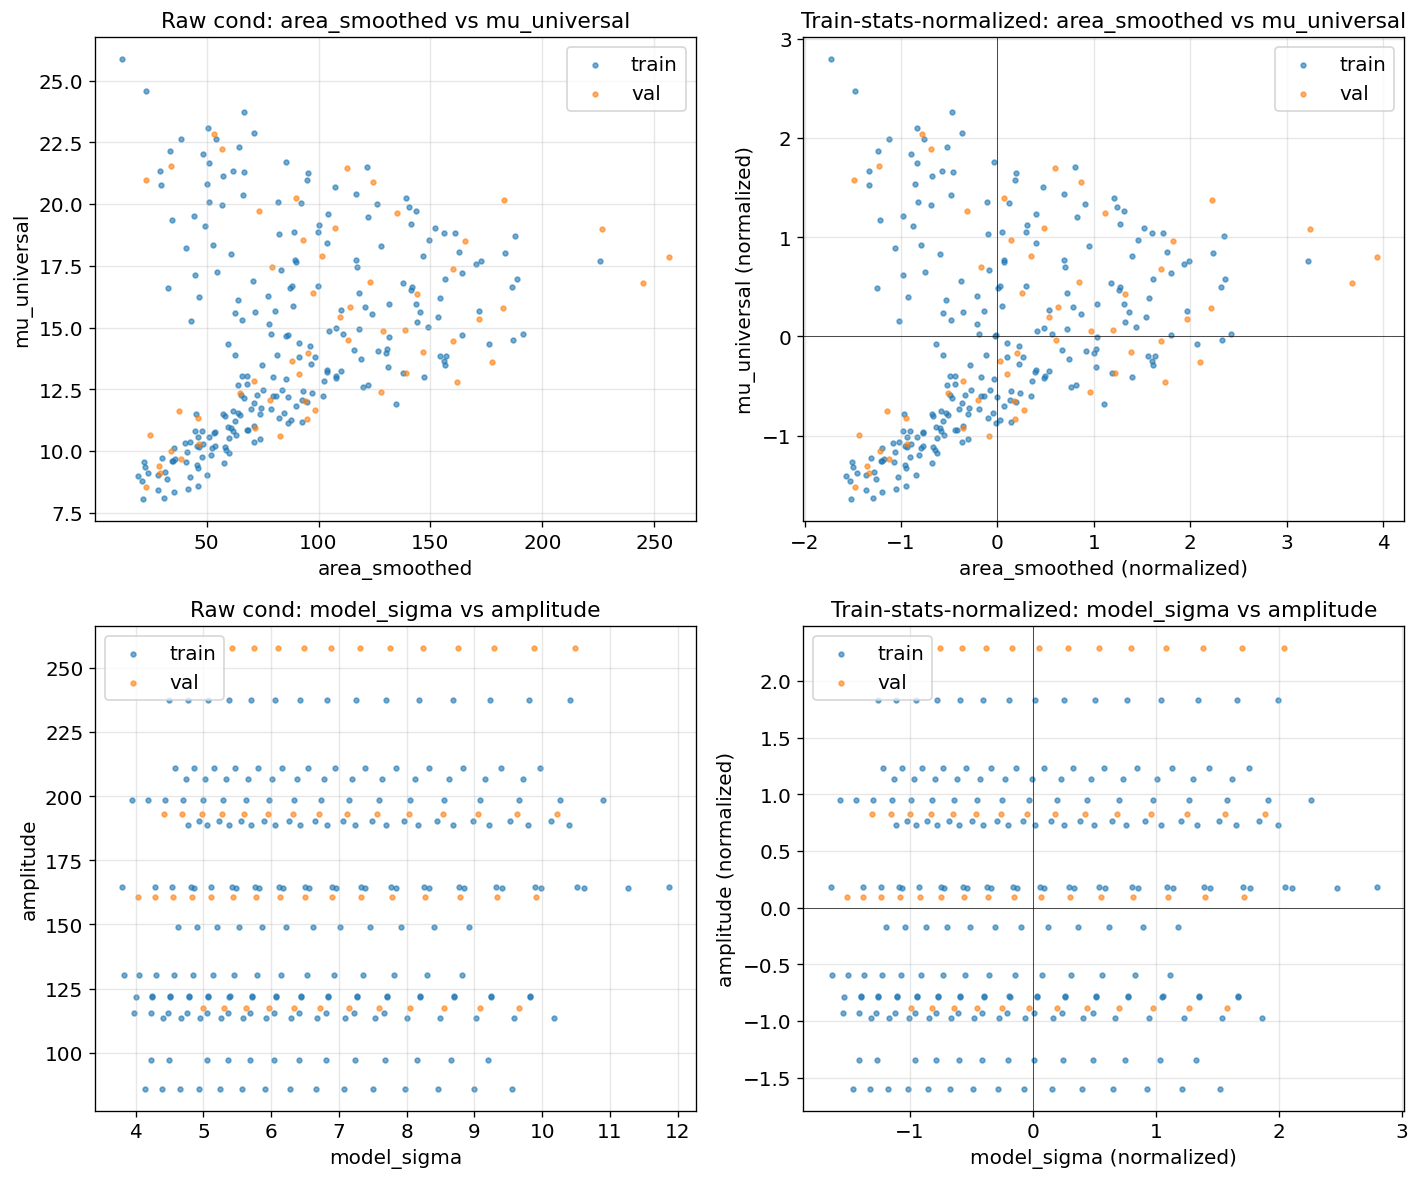

In [5]:
# Task 46 — instantiate, sanity-check, visualize the conditional datasets.

# 1. Instantiate both datasets. The train dataset computes its own
#    cond_means / cond_stds; val inherits those statistics through
#    the train-split-only normalization built into __init__.
train_dataset = ConditionalResidualDataset(windows_df, "train")
val_dataset   = ConditionalResidualDataset(windows_df, "val")

print(f"len(train_dataset) = {len(train_dataset)}")
print(f"len(val_dataset)   = {len(val_dataset)}")

# 2. Verify __getitem__ returns the right dict.
item = train_dataset[0]
assert isinstance(item, dict), f"expected dict, got {type(item).__name__}"
assert set(item.keys()) == {"r_clean", "cond"}, f"unexpected keys: {set(item.keys())}"
assert item["r_clean"].shape == (15,)
assert item["cond"].shape    == (4,)
assert item["r_clean"].dtype == torch.float32
assert item["cond"].dtype    == torch.float32
assert torch.isfinite(item["r_clean"]).all() and torch.isfinite(item["cond"]).all()
print(f"train_dataset[0]: r_clean shape={tuple(item['r_clean'].shape)}, "
      f"cond shape={tuple(item['cond'].shape)}")

# 3. cond_means / cond_stds must be identical across both splits.
assert torch.allclose(train_dataset.cond_means, val_dataset.cond_means)
assert torch.allclose(train_dataset.cond_stds,  val_dataset.cond_stds)
print(f"shared cond_means = {train_dataset.cond_means.numpy()}")
print(f"shared cond_stds  = {train_dataset.cond_stds.numpy()}")

# 4. Per-split mean / std of the normalized cond. Train must be ~0/1;
#    val will deviate from 0/1 — that deviation IS the point of
#    using train-split-only stats.
for name, ds in [("train", train_dataset), ("val", val_dataset)]:
    m = ds._cond.mean(dim=0).numpy()
    s = ds._cond.std(dim=0).numpy()
    print(f"  {name:5s}: normalized cond mean={m}, std={s}")
assert torch.allclose(train_dataset._cond.mean(dim=0), torch.zeros(4), atol=1e-4)
assert torch.allclose(train_dataset._cond.std(dim=0),  torch.ones(4),  atol=1e-4)

# 5. Plot raw and normalized cond clouds, coloured by split. The cond
#    vector is 4-dim now, so we lay it out as two pairs in a 2x2 panel:
#    top row = (area_smoothed, mu_universal), bottom row = (model_sigma,
#    amplitude). Left column = raw, right column = train-stats-normalized.
PAIRS = [
    (0, 1, "area_smoothed", "mu_universal"),
    (2, 3, "model_sigma",   "amplitude"),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
colors = {"train": "C0", "val": "C1"}
for row, (i, j, xname, yname) in enumerate(PAIRS):
    ax_raw, ax_norm = axes[row]
    for name, ds in [("train", train_dataset), ("val", val_dataset)]:
        raw = ds._cond * ds.cond_stds + ds.cond_means
        ax_raw.scatter(raw[:, i], raw[:, j], s=8, alpha=0.6,
                       color=colors[name], label=name)
        ax_norm.scatter(ds._cond[:, i], ds._cond[:, j], s=8, alpha=0.6,
                        color=colors[name], label=name)
    ax_raw.set_xlabel(xname); ax_raw.set_ylabel(yname)
    ax_raw.set_title(f"Raw cond: {xname} vs {yname}"); ax_raw.legend()
    ax_norm.set_xlabel(f"{xname} (normalized)"); ax_norm.set_ylabel(f"{yname} (normalized)")
    ax_norm.set_title(f"Train-stats-normalized: {xname} vs {yname}")
    ax_norm.axhline(0, color="k", linewidth=0.4); ax_norm.axvline(0, color="k", linewidth=0.4)
    ax_norm.legend()
plt.tight_layout(); plt.show()


---
## Task 47 — Build the DataLoaders

Same DataLoader pattern as Week 08. PyTorch's default collation handles
the Dataset's dict return automatically: each key in the per-item dict
becomes a key in the per-batch dict, with the leading batch dimension
prepended to every tensor value. So `next(iter(train_loader))` is a
dict:

```
{"r_clean": (B, 15) float32, "cond": (B, 4) float32}
```

Verify this explicitly — the LightningModule's `_shared_step` will read
from these keys, and a tuple-returning Dataset (from accidentally writing
`return r, cond` instead of `return {"r_clean": r, "cond": cond}` in
`__getitem__`) will give batches that look superficially similar but
fail in the training step several layers deeper.


In [6]:
# Task 47 — DataLoaders + batch sanity check.

BATCH_SIZE = 64

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE,
                                           shuffle=True,  num_workers=0)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                                           shuffle=False, num_workers=0)

for name, loader in [("train", train_loader), ("val", val_loader)]:
    batch = next(iter(loader))
    assert isinstance(batch, dict), f"expected dict, got {type(batch).__name__}"
    assert set(batch.keys()) == {"r_clean", "cond"}, f"wrong keys: {set(batch.keys())}"
    assert batch["r_clean"].shape[1] == 15 and batch["cond"].shape[1] == 4
    assert batch["r_clean"].dtype == torch.float32
    assert batch["cond"].dtype    == torch.float32
    print(f"{name:5s}: {len(loader):3d} batches/epoch, "
          f"r_clean shape={tuple(batch['r_clean'].shape)}, "
          f"cond shape={tuple(batch['cond'].shape)}")


train:   4 batches/epoch, r_clean shape=(64, 15), cond shape=(64, 4)
val  :   1 batches/epoch, r_clean shape=(55, 15), cond shape=(55, 4)


---
## Task 48 — `ConditionalDiffusionMLP` (template in `conditioned_infrastructure.py`)

The forward signature changes from `(r_t, t) → eps_hat` to
`(r_t, t, cond) → eps_hat`. The conditioning vector is concatenated
alongside r_t and the timestep embedding at the input layer:

```
x = torch.cat([r_t, t_emb, cond], dim=-1)   # shape (B, 15 + 128 + 4)
```

No new architectural concepts beyond that. The `TimestepEmbedding` is
reused unchanged from Week 08, imported from `unconditioned_infrastructure.py`.

**Open `conditioned_infrastructure.py` and implement** the `__init__` and
`forward` of `ConditionalDiffusionMLP`. Default constructor arguments
are pinned to match what the rest of this notebook expects.

---
## Task 49 — Sanity tests: t-sensitivity *and* cond-sensitivity

Week 08 introduced the t-sensitivity check: hold r_t fixed, vary t,
verify the output measurably changes. That check defends against a
silently-broken timestep embedding.

The conditional model needs the analogous check for the conditioning:
**cond-sensitivity** — hold r_t and t fixed, vary `cond` across the
range of `(area, mu, σ, A)` values the model will actually see, verify
the output measurably changes. If it does not, your model is silently
unconditional no matter what the class name says, and every
distributional comparison in the evaluation notebook will give answers
that look reasonable but are not measuring what you think they are.

Because cond now has four dimensions, a global "any cond change moves the
output" assertion is not strict enough: a model that wires only the first
two cond channels into the network would still pass it while silently
ignoring `model_sigma` and `amplitude`. So the check below sweeps the
**four cond dimensions independently** — each row of the test batch
perturbs exactly one cond channel by ±2 in normalized space and leaves
the rest at zero — and asserts that *each* perturbation moves the
output away from the all-zeros baseline. That catches per-channel
silent-drop, not just a wholesale ignored cond input.

Run **both** checks on a freshly-initialized model before training. The
checks are inexpensive; the failure modes they catch are exactly the
kind of silent corruption that wastes days of training time.

For the cond-sensitivity check, use a *realistic* range of conditioning
values — perturb each channel to roughly ±2 standard deviations of the
train distribution (the normalized range the model will actually
encounter), not arbitrary synthetic values. This makes the check both
more meaningful and a closer analogue of the t-sensitivity check, which
uses real timestep values.

t-sensitivity            : max off-diagonal L2 = 0.0082  (must be > 0)
cond-sensitivity per chan:
    area_smoothed : L2 from baseline = 0.0080  (must be > 0)
    mu_universal  : L2 from baseline = 0.0101  (must be > 0)
    model_sigma   : L2 from baseline = 0.0132  (must be > 0)
    amplitude     : L2 from baseline = 0.0073  (must be > 0)
cond-sensitivity worst   : min per-channel L2 = 0.0073


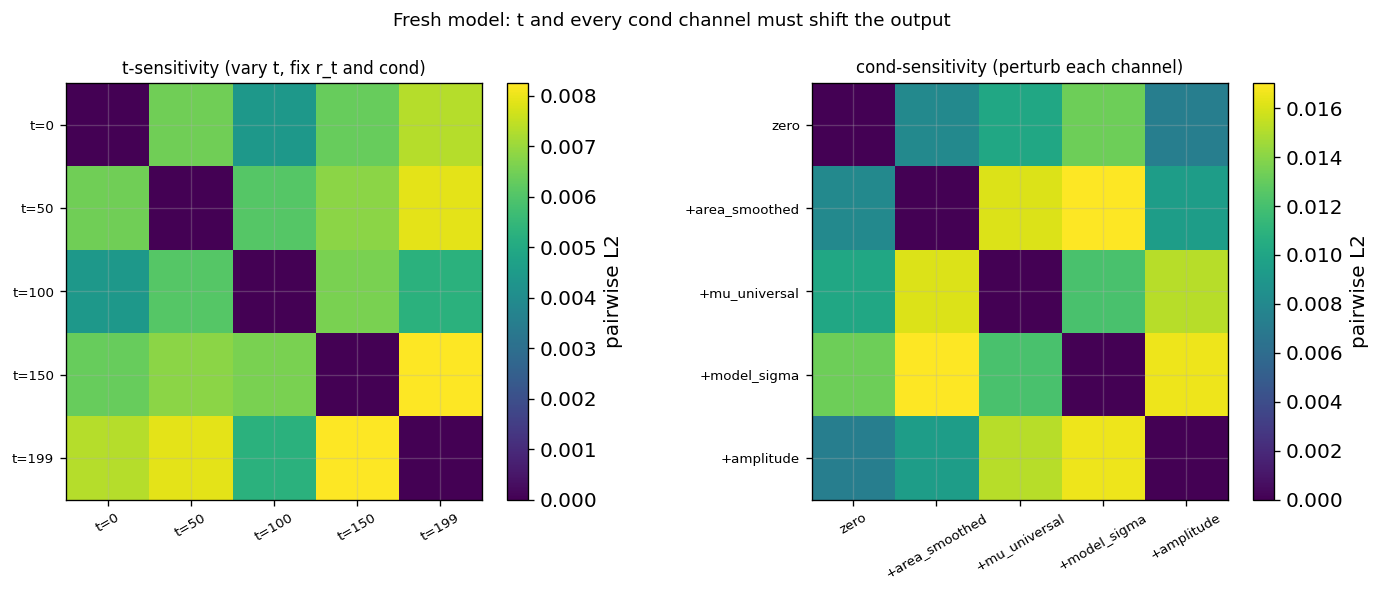

In [7]:
# Task 49 — t-sensitivity + per-channel cond-sensitivity on a fresh model.

torch.manual_seed(1)
model_test = ConditionalDiffusionMLP()

COND_NAMES = ["area_smoothed", "mu_universal", "model_sigma", "amplitude"]
N_COND_DIM = len(COND_NAMES)

r_t_fixed = torch.randn(15)
t_values  = torch.tensor([0, T//4, T//2, 3*T//4, T-1], dtype=torch.long)
cond_zero = torch.zeros(N_COND_DIM)                                   # mid-range cond

# 1. t-sensitivity: hold r_t and cond fixed, vary t.
r_t_batch_t  = repeat(r_t_fixed, "d -> n d", n=5)
cond_batch_t = repeat(cond_zero, "d -> n d", n=5)
with torch.no_grad():
    out_t = model_test(r_t_batch_t, t_values, cond_batch_t)
dist_t = (out_t[None] - out_t[:, None]).norm(dim=-1)                  # (5, 5)

# 2. cond-sensitivity: hold r_t and t fixed, vary each cond channel
#    independently. Row 0 is the zero baseline; rows 1..N_COND_DIM each
#    perturb a single channel by +2 in normalized space, leaving the rest
#    at zero. This catches a model that silently drops any one of the
#    cond channels — a global "any change moves the output" check would
#    not.
cond_values = torch.zeros(1 + N_COND_DIM, N_COND_DIM)
for j in range(N_COND_DIM):
    cond_values[1 + j, j] = 2.0
n_c        = cond_values.shape[0]
r_t_batch_c = repeat(r_t_fixed, "d -> n d", n=n_c)
t_fixed     = torch.full((n_c,), T // 2, dtype=torch.long)
with torch.no_grad():
    out_c = model_test(r_t_batch_c, t_fixed, cond_values)
dist_c = (out_c[None] - out_c[:, None]).norm(dim=-1)                  # (n_c, n_c)

# Per-channel sensitivities: distance from baseline (row 0) to each
# single-channel perturbation. EACH must be > 0.
per_channel_l2 = dist_c[0, 1:]                                        # (N_COND_DIM,)
max_off_t = dist_t[~torch.eye(5, dtype=torch.bool)].max().item()
min_off_c = per_channel_l2.min().item()
print(f"t-sensitivity            : max off-diagonal L2 = {max_off_t:.4f}  (must be > 0)")
print(f"cond-sensitivity per chan:")
for name, l2 in zip(COND_NAMES, per_channel_l2.tolist()):
    print(f"    {name:14s}: L2 from baseline = {l2:.4f}  (must be > 0)")
print(f"cond-sensitivity worst   : min per-channel L2 = {min_off_c:.4f}")
assert max_off_t > 0, "t-sensitivity is zero — the timestep embedding is being silently dropped"
assert min_off_c > 0, ("cond-sensitivity is zero on at least one channel — "
                       "a cond input is being silently dropped")

# Side-by-side heatmaps.
cond_labels = ["zero"] + [f"+{n}" for n in COND_NAMES]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(dist_t.numpy(), cmap="viridis")
axes[0].set_xticks(range(5)); axes[0].set_xticklabels([f"t={int(v)}" for v in t_values],
                                                      rotation=30, fontsize=8)
axes[0].set_yticks(range(5)); axes[0].set_yticklabels([f"t={int(v)}" for v in t_values], fontsize=8)
axes[0].set_title("t-sensitivity (vary t, fix r_t and cond)", fontsize=10)
fig.colorbar(im0, ax=axes[0], fraction=0.046, label="pairwise L2")

im1 = axes[1].imshow(dist_c.numpy(), cmap="viridis")
axes[1].set_xticks(range(n_c)); axes[1].set_xticklabels(cond_labels, rotation=30, fontsize=8)
axes[1].set_yticks(range(n_c)); axes[1].set_yticklabels(cond_labels, fontsize=8)
axes[1].set_title("cond-sensitivity (perturb each channel)", fontsize=10)
fig.colorbar(im1, ax=axes[1], fraction=0.046, label="pairwise L2")

fig.suptitle("Fresh model: t and every cond channel must shift the output", fontsize=11)
plt.tight_layout(); plt.show()

---
## Task 50 — `ConditionalDiffusionLightning` (template in `conditioned_infrastructure.py`)

The only structural changes from Week 08's `DiffusionLightning`:

1. `_shared_step` reads `batch["r_clean"]` and `batch["cond"]` from the
   dict batch (rather than unpacking a tuple) and passes `cond` through
   to `self.model(r_t, t, cond)`.
2. The constructor accepts `cond_means` and `cond_stds` and registers them
   as buffers alongside the existing `bin_means` / `bin_stds`. This keeps
   *all* relevant standardization statistics on the checkpoint, so the
   evaluation notebook can load and re-normalize conditioning without
   needing the training-time dataset.
3. `save_hyperparameters(ignore=[...])` now ignores the four statistics
   tensors alongside `model`, `alpha`, `sigma`.

The `configure_optimizers` method is *identical* to Week 08's. Copy it
from `unconditioned_infrastructure.py`.

**Open `conditioned_infrastructure.py` and implement** `__init__`,
`_shared_step`, and `configure_optimizers`. The `training_step` and
`validation_step` are filled in for you — they call `_shared_step` and
log loss exactly as in Week 08.

---
## Task 51 — Train the conditional model


In [11]:
# Task 51 — Train the conditional model.
#
# Two pieces of plumbing first:
#   (a) Assemble the de-standardized train/val residual arrays the
#       SampleQualityCallback wants for its periodic distributional checks.
#   (b) Subclass SampleQualityCallback to call sample_conditional instead
#       of sample, with a fixed batch of train-set conditioning vectors.
#       The base callback's sample(pl_module, batch_size=...) call would
#       break against the conditional model — sample() has no cond arg.

from infrastructure.utils.reproducibility import set_all_seeds
set_all_seeds(42)

# (a) De-standardize train/val residuals for the callback.
bin_means_np = train_dataset.bin_means.numpy()
bin_stds_np  = train_dataset.bin_stds.numpy()
all_train_std = torch.stack([train_dataset[i]["r_clean"]
                             for i in range(len(train_dataset))]).numpy()
all_val_std   = torch.stack([val_dataset[i]["r_clean"]
                             for i in range(len(val_dataset))]).numpy()
all_train_phys = all_train_std * bin_stds_np + bin_means_np
all_val_phys   = all_val_std   * bin_stds_np + bin_means_np

# (b) Conditional-aware SampleQualityCallback.
N_COMPARE = 500


class ConditionalSampleQualityCallback(SampleQualityCallback):
    """SampleQualityCallback variant that uses sample_conditional with a
    fixed batch of train-set conditioning vectors. Everything else — the
    bin-wise std MSE, the covariance Frobenius distance, the
    end-of-training figure panels — is unchanged from the base class.
    """

    def __init__(self, train_samples, cond_reference, **kwargs):
        super().__init__(train_samples, **kwargs)
        # cond_reference: (n_compare, cond_dim) tensor, ALREADY normalized.
        # We keep it on CPU here and move to the trainer device at call time.
        self._cond_ref = cond_reference.detach().clone()

    def _sample(self, pl_module):
        device = next(pl_module.parameters()).device
        return sample_conditional(pl_module, self._cond_ref, device=device).cpu().numpy()

    def on_train_epoch_end(self, trainer, pl_module):
        if trainer.current_epoch % self.every != 0:
            return
        samples = self._sample(pl_module)
        sample_std = samples.std(0)
        sample_cov = np.cov(samples, rowvar=False)
        std_mse  = float(np.mean((sample_std - self.train_arr.std(0)) ** 2))
        cov_dist = float(np.linalg.norm(sample_cov - np.cov(self.train_arr, rowvar=False)))
        pl_module.log("sample_std_mse",  std_mse)
        pl_module.log("sample_cov_frob", cov_dist)
        if self.val_arr is not None:
            val_std_mse  = float(np.mean((sample_std - self.val_arr.std(0)) ** 2))
            val_cov_dist = float(np.linalg.norm(sample_cov - np.cov(self.val_arr, rowvar=False)))
            pl_module.log("val_sample_std_mse",  val_std_mse)
            pl_module.log("val_sample_cov_frob", val_cov_dist)
        pl_module.train()

    def on_train_end(self, trainer, pl_module):
        if not isinstance(trainer.logger, WandbLogger):
            return
        if self.bin_centers is None:
            return
        try:
            import wandb as _wandb
        except ImportError:
            return

        samples = self._sample(pl_module)
        rng     = np.random.default_rng(0)
        idx     = rng.integers(0, len(self.train_arr), size=samples.shape[0])
        train_np = self.train_arr[idx]
        w = self.bin_width * 0.4

        fig_mean, ax = plt.subplots(figsize=(9, 4))
        ax.bar(self.bin_centers - w / 2, train_np.mean(axis=0), width=w,
               color="C0", label="training",      edgecolor="black", linewidth=0.4)
        ax.bar(self.bin_centers + w / 2, samples.mean(axis=0),  width=w,
               color="C2", label="model samples", edgecolor="black", linewidth=0.4)
        ax.axhline(0, color="k", linewidth=0.4)
        ax.set_xlabel("|latitude| (°)"); ax.set_ylabel("mean residual")
        ax.set_title("End-of-training: bin-wise mean — training vs. conditional samples")
        ax.legend(); fig_mean.tight_layout()

        fig_std, ax = plt.subplots(figsize=(9, 4))
        ax.bar(self.bin_centers - w / 2, train_np.std(axis=0), width=w,
               color="C0", label="training",      edgecolor="black", linewidth=0.4)
        ax.bar(self.bin_centers + w / 2, samples.std(axis=0),  width=w,
               color="C2", label="model samples", edgecolor="black", linewidth=0.4)
        ax.set_xlabel("|latitude| (°)"); ax.set_ylabel("std residual")
        ax.set_title("End-of-training: bin-wise std — training vs. conditional samples")
        ax.legend(); fig_std.tight_layout()

        trainer.logger.experiment.log({
            "eval/binwise_mean":    wandb.Image(fig_mean),
            "eval/binwise_std":     wandb.Image(fig_std),
            "eval/end_of_training": float(trainer.current_epoch),
            "trainer/global_step":  trainer.global_step,
        })
        plt.close(fig_mean); plt.close(fig_std)


# Pick a fixed batch of cond vectors from the train dataset — already in
# train-stats-normalized space because the dataset standardizes its _cond.
rng = np.random.default_rng(0)
ref_idx  = rng.integers(0, len(train_dataset), size=N_COMPARE)
cond_ref = train_dataset._cond[ref_idx].clone()

# Model + LightningModule.
MAX_EPOCHS = 20000
model_cond = ConditionalDiffusionMLP()
lightning_cond = ConditionalDiffusionLightning(
    model=model_cond, alpha=alpha_np, sigma=sigma_np, T=T, lr=1e-3,
    scheduler="cosine", weight_decay=1e-4,
    bin_means=train_dataset.bin_means, bin_stds=train_dataset.bin_stds,
    cond_means=train_dataset.cond_means, cond_stds=train_dataset.cond_stds,
)

# Logger — try WandB, fall back to CSV.
try:
    logger_cond = WandbLogger(
        project="butterflai-wk10-amj",
        name=f"conditional_b{BATCH_SIZE}_e{MAX_EPOCHS}_cos",
        save_dir="./wandb_logs",
    )
except Exception as _e:
    print(f"WandB unavailable ({_e}); using CSVLogger.")
    logger_cond = CSVLogger("./csv_logs", name="conditional")

sample_quality_cb = ConditionalSampleQualityCallback(
    train_samples=all_train_phys, val_samples=all_val_phys,
    cond_reference=cond_ref,
    every_n_epochs=100, n_compare=N_COMPARE,
    bin_centers=BIN_CENTERS, bin_width=BIN_WIDTH,
)

trainer_cond = pl.Trainer(
    max_epochs=MAX_EPOCHS, logger=logger_cond,
    accelerator="auto", devices="auto",
    log_every_n_steps=10, enable_progress_bar=False,
    callbacks=[sample_quality_cb],
)

trainer_cond.fit(lightning_cond, train_loader, val_loader)
try:
    wandb.finish()
except Exception:
    pass


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


INFO:pytorch_lightning.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:321: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ ConditionalDiffusionMLP │ 78.7 K │ train │     0 │
└───┴───────┴─────────────────────────┴────────┴───────┴───────┘

Trainable params: 78.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 78.7 K                                                                                               
Total estimated model params size (MB): 0.315                                                                      
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
INFO:pytorch_lightning.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...


KeyboardInterrupt: 

In [12]:
import os

# Create the directory if it doesn't exist
checkpoint_dir = '/content/drive/MyDrive/Colab_Checkpoints/week_10'
os.makedirs(checkpoint_dir, exist_ok=True)

# Save the checkpoint
trainer_cond.save_checkpoint(os.path.join(checkpoint_dir, 'ckpt_conditional.ckpt'))
print(f"Checkpoint saved to {os.path.join(checkpoint_dir, 'ckpt_conditional.ckpt')}")

INFO:pytorch_lightning.trainer.connectors.checkpoint_connector:`weights_only` was not set, defaulting to `False`.


Checkpoint saved to /content/drive/MyDrive/Colab_Checkpoints/week_10/ckpt_conditional.ckpt


---
## Handoff to `10b_conditioned_evaluate.ipynb`

You should now have one checkpoint file in this directory:
- `ckpt_conditional.ckpt` (conditional diffusion model)

Together with the Week 08 unconditional checkpoint `ckpt_full.ckpt`, this
gives the evaluation notebook two trained models to compare. The
evaluation notebook will:

- Reload both checkpoints and re-verify their t-sensitivity (and, for the
  conditional model, cond-sensitivity) on the *loaded* state — defends
  against silent state-dict corruption during loading.
- Sample residuals from the conditional model targeted at specific
  validation-window conditioning, visualize them.
- Compare the conditional samples' distribution to held-out validation
  residuals, against the unconditional baseline.

The headline value-add metric — `compute_global_nll` on the held-out
validation split, classical alone vs. classical + conditional residuals —
is its own notebook (`10c_diffusion_NLL_evaluation.ipynb`). That's the
question the program has been pointing at since Week 03, and it gets its
own clean space to be answered.

**If you change anything in `conditioned_infrastructure.py` after this notebook
has been run**, the autoreload magic in the evaluation notebook will pick
it up — but checkpoints saved with the old code will not be compatible
with new class signatures. If you change a class signature, retrain.
